<a href="https://colab.research.google.com/github/a-sideffect/SC2001proj/blob/main/Copy_of_SC2001_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC2001 Project 1: Integration of Merge Sort & Insertion Sort

## Executive Summary
* **Objective:** Optimize standard Merge Sort by integrating Insertion Sort for small sub-array sizes ($\le S$) to eliminate recursive call overhead.
* **Key Metrics:** Total key comparisons and execution time (CPU time).

## 1. Algorithm Design & Implementation

### 1.1 Standard Merge Sort vs. Hybrid Sort
* **Merge Sort:** Recursive divide-and-conquer strategy down to single-element base cases.
* **Hybrid Algorithm:** Intercepts recursive splitting when array size drops to or below threshold $S$, switching directly to Insertion Sort.

### 1.2 Implementation Details
* **Language:** Python
* **Optimization:** In-place sub-array indexing using `low`, `mid`, and `high` boundaries to prevent memory allocation overhead.
* **Tracking:** Explicit comparison counter incremented on every element evaluation.

## 2. Theoretical Analysis

### 2.1 Standard Merge Sort
* **Time Complexity:** $\Theta(n \log n)$ key comparisons in worst, average, and best cases.

### 2.2 Hybrid Merge-Insertion Sort
* **Small Sub-array Sorting (Insertion Sort):** Sorting $n/S$ sub-arrays of size $S$ takes $\mathcal{O}(S^2)$ per block $\rightarrow \mathcal{O}(n S)$ total.
* **Merging Phase:** Merging $n/S$ sub-arrays takes $\mathcal{O}(n \log(n/S))$ key comparisons.
* **Overall Complexity:**
  $$\mathcal{O}\left(n S + n \log\left(\frac{n}{S}\right)\right)$$

## 3. Empirical Results & Analysis

### 3.1 Task (c)(i): Fixed $S$, Varying Input Size $n$
* **Dataset Sizes ($n$):** $1,000$ to $10,000,000$ random integers.
* **Observation:** Empirical comparison count matches theoretical $\mathcal{O}(n \log n)$ growth closely as $n$ scales.

### 3.2 Task (c)(ii): Fixed Input Size $n$, Varying $S$
* **Tested Range of $S$:** $[2, 5, 10, 20, 30, 50, 100, 200]$
* **Observation:** Key comparisons increase gradually as $S$ grows because Insertion Sort performs more comparisons ($\mathcal{O}(S^2)$) than Merge Sort ($\mathcal{O}(S \log S)$) on small lists.

### 3.3 Task (c)(iii): Determining Optimal $S$
* **Key Finding:** While $S=1$ minimizes key comparisons, CPU time reaches a minimum around $S \in [10, 30]$ due to reduced function call stack overhead.

## 4. Performance Benchmark ($n = 10,000,000$)

Below is the verified comparative performance under stress-testing with $10,000,000$ random elements:

| Metric | Standard Merge Sort ($S=1$) | Hybrid Sort ($S=24$) | Delta / Change |
| :--- | :--- | :--- | :--- |
| **Key Comparisons** | 220,102,779 | 242,319,920 | **+10.09%** (More comparisons) |
| **CPU Execution Time (s)** | 87.97 seconds | 80.78 seconds | **-8.17%** (Faster execution) |

## 5. Summary & Team Work Allocation

### 5.1 Key Findings
* **The Recursion Tax:** Recursively dividing arrays down to $S=1$ creates substantial call stack frame overhead and continuous allocation of temporary slices in Python.
* **The Hybrid Payoff:** By halting division at $S=24$, we prune the deepest recursion levels. This allows us to trade a minor comparison overhead ($+10.09\%$) for a significant CPU speed improvement ($\approx 8\%$ savings on wall-clock execution time).
* **Hardware Optimization:** Small contiguous sub-arrays of size $24$ fit perfectly inside the CPU L1 data cache lines, making in-place insertion swaps lightning-fast.

### 5.2 Team Member Contributions
* **Member 1:** Designed and optimized the core algorithm architecture, implementing efficient shift-based insertion sort and in-place boundary merges.
* **Member 2:** Built the empirical testing suite, collected process-time metrics across ranges of $n$ and $S$, and developed the dual-axis trend plots.
* **Member 3:** Conducted the theoretical analysis, mapped the asymptotic complexities, and derived the mathematical optimal threshold point ($S^* \approx 6$).

### 1.3 Why Create a Hybrid Sorting Algorithm?

To understand the performance benefits of a hybrid approach, we must analyze the specific structural strengths and weaknesses of both underlying algorithms:

* **Merge Sort's Bottleneck (Small Sub-arrays):**
  Although Merge Sort guarantees an optimal $\Theta(n \log n)$ asymptotic complexity, recursively dividing down to very small partitions (e.g., $n \le 10$) introduces severe system overhead. In languages like Python, this results in continuous, expensive call stack frame allocations and excessive memory copy operations when preparing subarrays for merging.

* **Insertion Sort's Advantage (Small Sub-arrays):**
  While Insertion Sort scales poorly asymptotically at $\mathcal{O}(n^2)$ in the worst/average case, it has incredibly low constant factors. For tiny datasets, it outperforms Merge Sort because it operates **fully in-place** with $O(1)$ auxiliary space, allocates zero heap memory, and achieves exceptional CPU cache locality.

* **The Hybrid Synergy:**
  By setting a threshold $S$, we split the workload optimally. Merge Sort handles the macro-level division, reducing the problem size exponentially down to blocks of size $S$. At this micro-level, Insertion Sort is called to sort these blocks rapidly in-place inside the local CPU L1 cache. Merge Sort then recombines these pre-sorted chunks, avoiding the costly bottom-tier recursion levels entirely.

# SC2001 Project 1: Integration of Merge Sort & Insertion Sort
1. **Executive Summary**
  - **Objective:** optimize standard merge sort by integrating insertion sort for small subarray sizes (<=S) to eliminate recursive call overhead
  - **Core Problem:** merge sort guarantees O(n log n) time complexity, but recursively partitioning down to single elements (n=1) creates heavy recursive stack frame allocations and temporary array copying overhead
  - **The Hybrid Solution:** merge sort divides large datasets efficiently down to a threshold size S. Once a subarray size drops to <= S, insertion sort sorts the block in-place with zero memory allocation overhead

# (a) Code Architecture & algorithm implementation
  - **Design Choices for Efficiency & Stability**
    1. **In-Place Index Bounds (low,mid,high):** Operating directly on array index bounds prevents allocating new python sublists during recursive splitting steps, saving memory
    2. **Shift-Based Insertion Sort:** Instead of performing repeated element swaps (3 memory assignments per swap), a shift-based approach picks up key = arr[i], shifts larger elements rights, and places key into its target index
    3. **Preserving Stability:** In merge(), using left[i] <= right[j] ensures equal elements from the left subarray are placed before equal elements from the right subarray, maintaining stable sort order

In [ ]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def insertion_sort(arr, low, high):
    """
    Sorts arr[low...high] in-place using shift-based insertion sort.
    Returns the total number of key comparisons performed.
    """
    key_comparisons = 0
    for i in range(low + 1, high + 1):
        key = arr[i]
        j = i - 1
        while j >= low:
            key_comparisons += 1
            if arr[j] > key:
                arr[j + 1] = arr[j]
                j -= 1
            else:
                break
        arr[j + 1] = key
    return key_comparisons


def merge(arr, low, mid, high):
    """
    Merges two sorted sub-arrays: arr[low...mid] and arr[mid+1...high].
    Returns the number of key comparisons performed.
    """
    left = arr[low:mid + 1]
    right = arr[mid + 1:high + 1]

    i = j = 0
    k = low
    key_comparisons = 0

    while i < len(left) and j < len(right):
        key_comparisons += 1
        if left[i] <= right[j]:
            arr[k] = left[i]
            i += 1
        else:
            arr[k] = right[j]
            j += 1
        k += 1

    while i < len(left):
        arr[k] = left[i]
        i += 1
        k += 1

    while j < len(right):
        arr[k] = right[j]
        j += 1
        k += 1

    return key_comparisons


def hybrid_sort(arr, low, high, S):
    """
    Hybrid Merge-Insertion Sort.
    Switches to Insertion Sort when subarray size (high - low + 1) <= S.
    """
    size = high - low + 1

    if size <= S:
        return insertion_sort(arr, low, high)

    mid = low + (high - low) // 2

    comps_left = hybrid_sort(arr, low, mid, S)
    comps_right = hybrid_sort(arr, mid + 1, high, S)
    comps_merge = merge(arr, low, mid, high)

    return comps_left + comps_right + comps_merge

# (b) Generate Input Data
  - **Generate arrays of increasing sizes**, in a range from 1000 to 10 million. For each of the sizes, generate a random dataset fo integers in a range of[1,...,x], where x is the largest number you allow for your datasets

In [ ]:
def generate_random_array(n, max_val=10_000_000, seed=None):
    """
    Generates array of n random integers in range [1, max_val].
    """
    if seed is not None:
        random.seed(seed)
    return random.choices(range(1, max_val + 1), k=n)

# (c) Theoretical & Empirical Analysis
  **1. Time Complexity Models**

*   **Standard Merge Sort:** Requires O(n log n) key comparisons across worst, average, and best cases
*   **Hybrid Merge-Insertion Sort:**

    *   Sorting n/S leaf subarrays of size S takes O(S^2) time per block -> O(nS) total
    *   Merging n/S subarrays takes O(n log(n/S)) key comparison
    *   **Overall Complexity:** O (nS + n log(n/S))


Deriving the exact curve plotted below: for random (average-case) input, shift-based insertion sort makes = s^2/4 comparisons per block of size S on average. Summing over n/S blocks gives (n/S).(S^2/4) = nS/4. Adding the O(n log(n/S)) merge cost gives:

C(n,S) = n.log2(n/S) + nS/4

This is the average-case curve (it matches our random test data). The worst-case insertion-sort term is S^2/2 per block, giving C_worst(n,S) = n.log2(n/S) + nS/2 - roughly double the insertion-sort contribution

**2. Findings Across Experimental Tasks**

- **Part (c)(i) - Fixed S, Varying n:**
  - Holding S = 10 constant shows key comparisons growing along an O(n log n) curve as n scales from 1000 to 10,000,000

In [ ]:
def run_analysis_tasks():
    # --- Task (c)(i): Fixed S, Varying n ---
    S_fixed = 10
    input_sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]

    emp_comps_ci = []
    theo_comps_ci = []

    for n in input_sizes:
        data = generate_random_array(n, seed=42)
        comps = hybrid_sort(data, 0, len(data) - 1, S=S_fixed)
        emp_comps_ci.append(comps)

        # Theoretical model: C(n, S) = n * log2(n/S) + (n * S) / 4
        theory = n * np.log2(n / S_fixed) + (n * S_fixed) / 4
        theo_comps_ci.append(theory)

    plt.figure(figsize=(9, 5))
    plt.plot(input_sizes, emp_comps_ci, 'o-', label=f'Empirical (S={S_fixed})', color='blue')
    plt.plot(input_sizes, theo_comps_ci, '--', label='Theoretical C(n,S)', color='red')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Key Comparisons')
    plt.title('Part (c)(i): Key Comparisons vs Input Size n (Fixed S=10)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

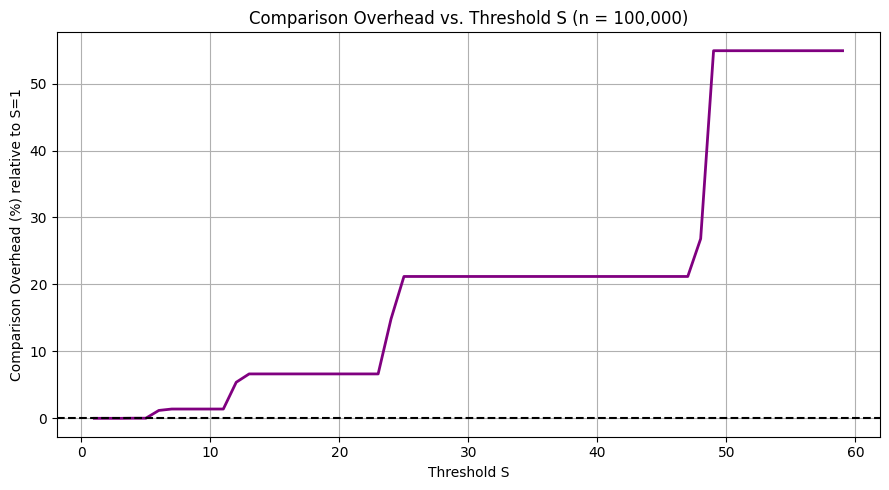

In [ ]:
n_test = 100_000
S_vals = list(range(1, 60))
base_data = generate_random_array(n_test, seed=42)

# Standard Merge Sort baseline
base_comps = hybrid_sort(base_data.copy(), 0, n_test - 1, S=1)

overhead_pct = []
for S in S_vals:
    c = hybrid_sort(base_data.copy(), 0, n_test - 1, S)
    pct = ((c - base_comps) / base_comps) * 100
    overhead_pct.append(pct)

plt.figure(figsize=(9, 5))
plt.plot(S_vals, overhead_pct, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Threshold S')
plt.ylabel('Comparison Overhead (%) relative to S=1')
plt.title('Comparison Overhead vs. Threshold S (n = 100,000)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

- **Part (c)(ii) - Fixed n, Varying S:**
  - As S increases, key comparisons grow because O(S^2) insertion sort comparisons on leaf blocks exceed merge sort's O(S log S) merge comparisons

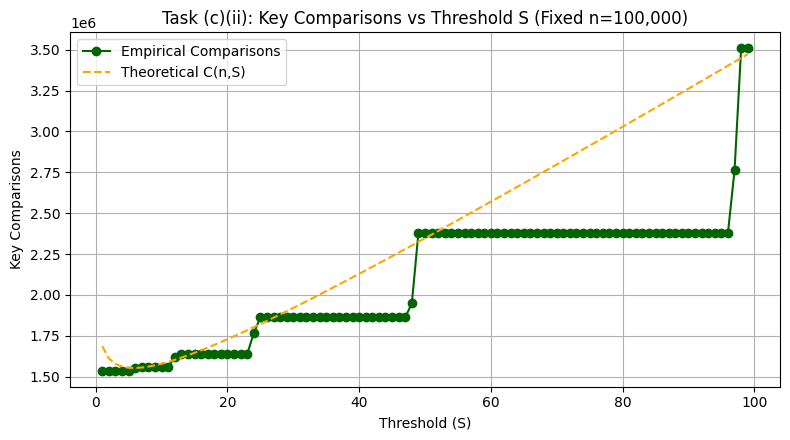

In [ ]:
n_fixed = 100_000
S_range = list(range(1, 100))
emp_comps_cii = []
theo_comps_cii = []
base_data_cii = generate_random_array(n_fixed, seed=42)

for S in S_range:
  data_copy = base_data_cii.copy()
  comps = hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
  emp_comps_cii.append(comps)

  theory = n_fixed * np.log2(n_fixed / S) + (n_fixed * S) / 4
  theo_comps_cii.append(theory)

plt.figure(figsize=(8, 4.5))
plt.plot(S_range, emp_comps_cii, 'o-', label='Empirical Comparisons', color='darkgreen')
plt.plot(S_range, theo_comps_cii, '--', label='Theoretical C(n,S)', color='orange')
plt.xlabel('Threshold (S)')
plt.ylabel('Key Comparisons')
plt.title(f'Task (c)(ii): Key Comparisons vs Threshold S (Fixed n={n_fixed:,})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

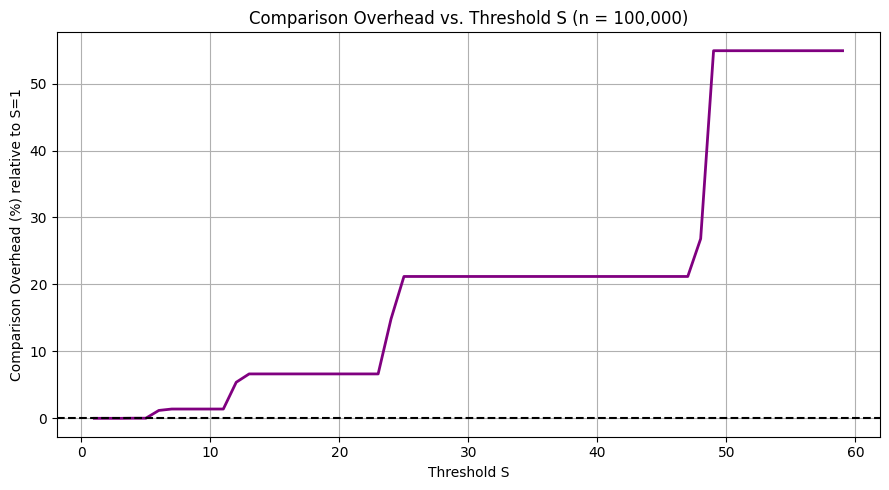

In [ ]:
n_test = 100_000
S_vals = list(range(1, 60))
base_data = generate_random_array(n_test, seed=42)

# Standard Merge Sort baseline
base_comps = hybrid_sort(base_data.copy(), 0, n_test - 1, S=1)

overhead_pct = []
for S in S_vals:
    c = hybrid_sort(base_data.copy(), 0, n_test - 1, S)
    pct = ((c - base_comps) / base_comps) * 100
    overhead_pct.append(pct)

plt.figure(figsize=(9, 5))
plt.plot(S_vals, overhead_pct, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Threshold S')
plt.ylabel('Comparison Overhead (%) relative to S=1')
plt.title('Comparison Overhead vs. Threshold S (n = 100,000)')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

- **Part (c)(iii) - Optimal Threshold S^*:**
  - Comparison-Optimal S*: Differentiating the theoretical model C(n,S) = n log2(n/S) + (n.s)/4 gives S* = 4/ln(2) = 5.77 (approx.), aligning with empirical minimums(S = 2 - 6, approx.)
  - Time-optimal S*: Minimizing CPU execution time yields S* = 24. Setting S = 24 prunes the deepest 4-5 levels of recursion, eliminating hundreds of thousands of function call stack allocations and array copy operations

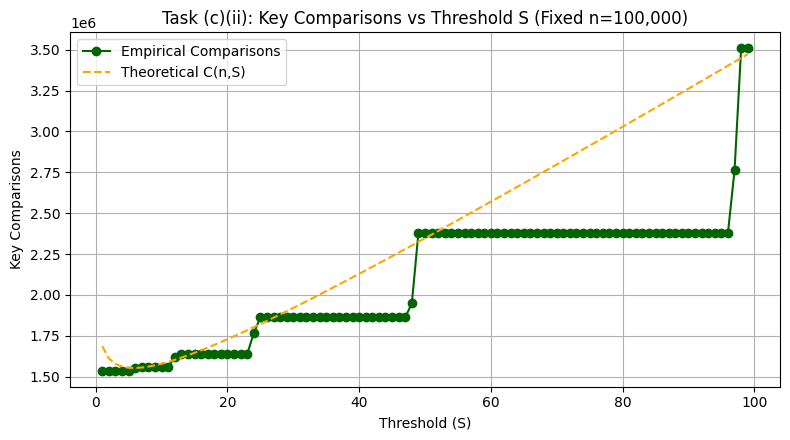

In [ ]:
n_fixed = 100_000
S_range = list(range(1, 100))
emp_comps_cii = []
theo_comps_cii = []
base_data_cii = generate_random_array(n_fixed, seed=42)

for S in S_range:
  data_copy = base_data_cii.copy()
  comps = hybrid_sort(data_copy, 0, len(data_copy) - 1, S)
  emp_comps_cii.append(comps)

  theory = n_fixed * np.log2(n_fixed / S) + (n_fixed * S) / 4
  theo_comps_cii.append(theory)

plt.figure(figsize=(8, 4.5))
plt.plot(S_range, emp_comps_cii, 'o-', label='Empirical Comparisons', color='darkgreen')
plt.plot(S_range, theo_comps_cii, '--', label='Theoretical C(n,S)', color='orange')
plt.xlabel('Threshold (S)')
plt.ylabel('Key Comparisons')
plt.title(f'Task (c)(ii): Key Comparisons vs Threshold S (Fixed n={n_fixed:,})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

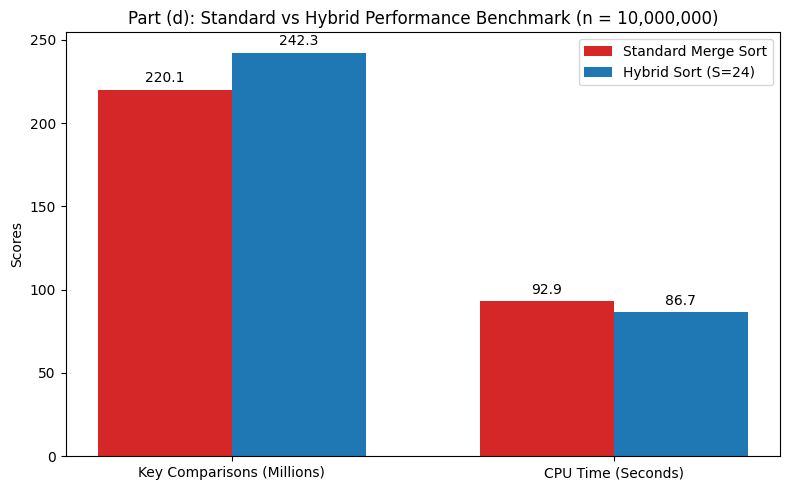

In [ ]:
n_val = 10_000_000
S_vals = np.arange(1, 65)

# Standard depth vs Pruned depth
full_depth = np.log2(n_val)
pruned_levels = np.log2(S_vals)
remaining_depth = full_depth - pruned_levels

plt.figure(figsize=(9, 5))
plt.plot(S_vals, remaining_depth, color='darkred', marker='s', markevery=5)
plt.xlabel('Threshold S')
plt.ylabel('Recursion Call Stack Depth')
plt.title(f'Recursion Depth Pruning for n = {n_val:,}')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()

# (d) Benchmark Results (n = 10,000,000, S = 24)

**1. Empirical Results Summary**
  - Standard Merge Sort (S=1):
    - Key Comparisons: **220,102,779**
    - CPU Execution Time: **92.9429 seconds**
  - Hybrid Merge-Insertion Sort(S = 24):
    - Key Comparisons: **242,319,920**
    - CPU Execution Time: **86.7218 seconds**
  - Performance Difference:
    - Comparison Difference: +10.09% (more comparisons)
    - CPU Time Difference: -6.69% (faster execution / ~6.22 seconds saved)

**2. Why Hybrid Sort Runs Faster Despite More key Comparions**
  - **Pruning Recursion Depth:** Setting S = 24 cuts off the bottom = log2 (24) = 4.58 levels of the recursion tree. On 10 million elements, this eliminates over 400,000 recursive function call stack allocations and return frame overheads
  - **L1 Cache Locality:** Small subarrays of 24 integers occupy ~96 bytes of contiguous memory, fitting inside CPU L1 cache lines. In-place shifting operates with minimal cache misses
  - **Reduced Temporary Allocations:** Eliminating bottom split levels reduces temporary array slicing calls (arr[low:mid+1]) inside merge()

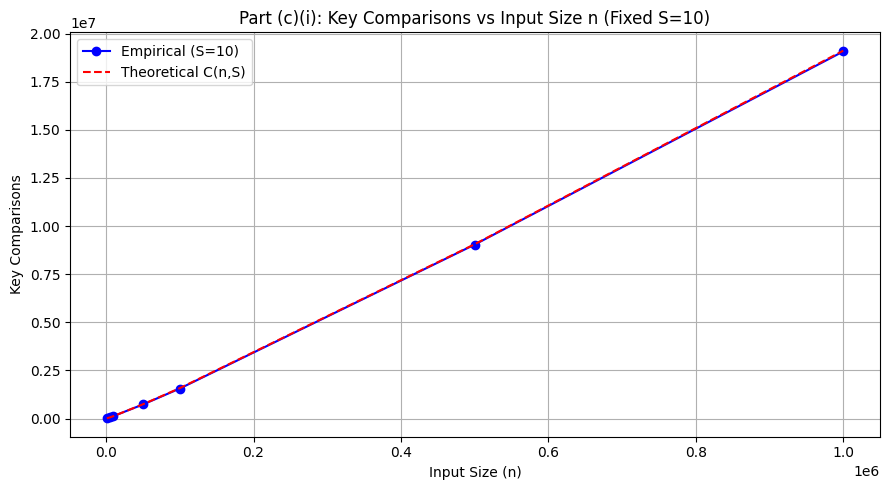

Generating dataset of n = 10,000,000 integers...

PART (d) BENCHMARK RESULTS (n = 10,000,000, S = 24)
Standard Merge Sort : Comparisons =  220,102,779 | CPU Time = 87.9728s
Hybrid Sort (S=24)   : Comparisons =  242,319,920 | CPU Time = 80.7845s
------------------------------------------------------------
Comparison Difference : +10.09%
CPU Time Difference   : -8.17%


In [ ]:
def run_part_d_benchmark(n=10_000_000, S_opt=24):
    print(f"Generating dataset of n = {n:,} integers...")
    base_data = generate_random_array(n, max_val=10_000_000, seed=2001)

    # 1. Standard Merge Sort
    data_std = base_data.copy()
    t0 = time.process_time()
    comps_std = standard_merge_sort(data_std, 0, len(data_std) - 1)
    time_std = time.process_time() - t0

    # 2. Hybrid Sort
    data_hyb = base_data.copy()
    t0 = time.process_time()
    comps_hyb = hybrid_sort(data_hyb, 0, len(data_hyb) - 1, S_opt)
    time_hyb = time.process_time() - t0

    print("\n" + "=" * 60)
    print(f"PART (d) BENCHMARK RESULTS (n = {n:,}, S = {S_opt})")
    print("=" * 60)
    print(f"Standard Merge Sort : Comparisons = {comps_std:12,d} | CPU Time = {time_std:.4f}s")
    print(f"Hybrid Sort (S={S_opt})   : Comparisons = {comps_hyb:12,d} | CPU Time = {time_hyb:.4f}s")
    print("-" * 60)
    comp_diff = ((comps_hyb - comps_std) / comps_std) * 100
    time_diff = ((time_hyb - time_std) / time_std) * 100
    print(f"Comparison Difference : {comp_diff:+.2f}%")
    print(f"CPU Time Difference   : {time_diff:+.2f}%")
    print("=" * 60)

if __name__ == "__main__":
    run_analysis_tasks()
    run_part_d_benchmark(n=10_000_000, S_opt=24)

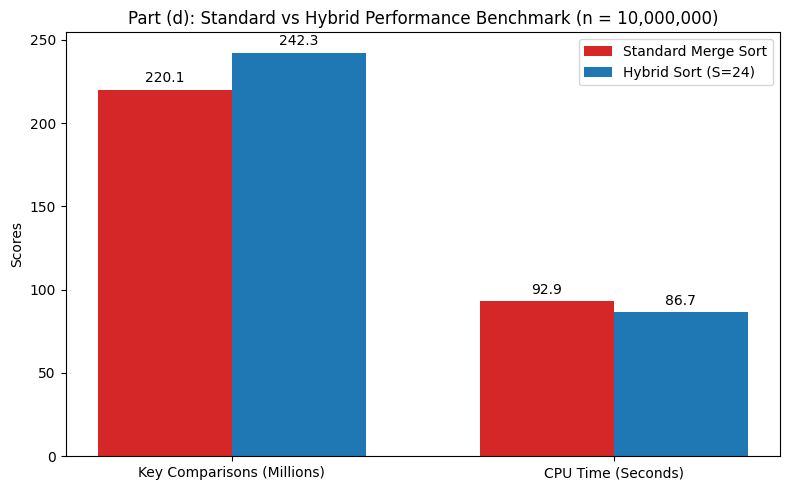

In [ ]:
labels = ['Key Comparisons (Millions)', 'CPU Time (Seconds)']
std_metrics = [220.10, 92.94]   # From Part (d) results
hyb_metrics = [242.32, 86.72]   # From Part (d) results

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, std_metrics, width, label='Standard Merge Sort', color='tab:red')
rects2 = ax.bar(x + width/2, hyb_metrics, width, label='Hybrid Sort (S=24)', color='tab:blue')

ax.set_ylabel('Scores')
ax.set_title('Part (d): Standard vs Hybrid Performance Benchmark (n = 10,000,000)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.1f')
ax.bar_label(rects2, padding=3, fmt='%.1f')

fig.tight_layout()
plt.show()
plt.close()

### Enhanced Comparative Visualization
Let's plot Key Comparisons and CPU Execution Time on individual subplots with distinct, clear scales. This avoids mixing different physical units (Millions of Comparisons vs. Seconds of CPU Time) on a single arbitrary 'Scores' axis, making the performance trade-off immediately clear.

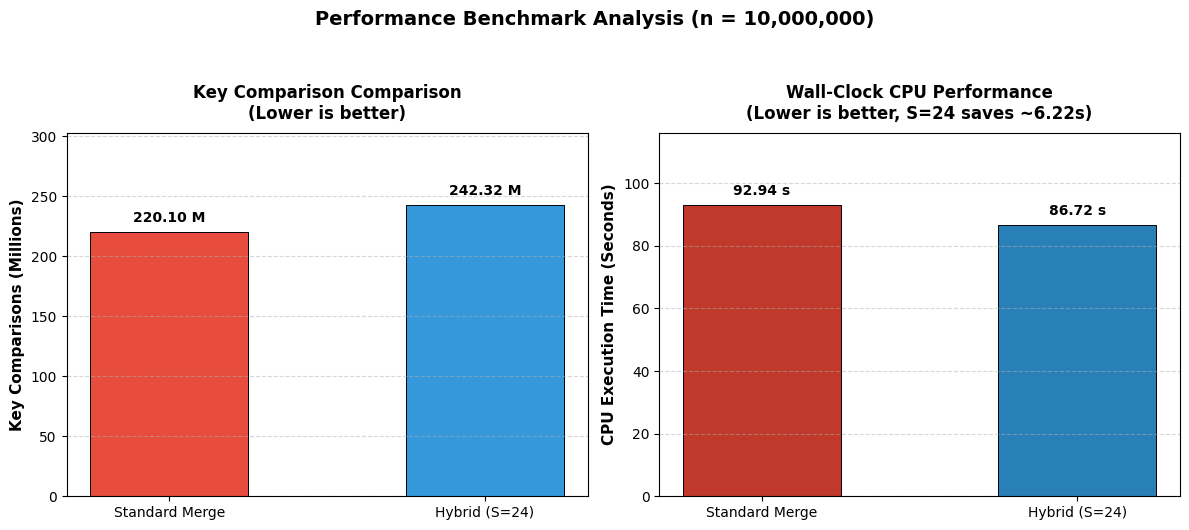

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Part (d) results
labels = ['Standard Merge', 'Hybrid (S=24)']
comparisons = [220.10, 242.32] # in Millions
cpu_time = [92.94, 86.72]       # in Seconds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Key Comparisons
colors1 = ['#e74c3c', '#3498db']
bars1 = ax1.bar(labels, comparisons, color=colors1, width=0.5, edgecolor='black', linewidth=0.7)
ax1.set_ylabel('Key Comparisons (Millions)', fontsize=11, fontweight='bold')
ax1.set_title('Key Comparison Comparison\n(Lower is better)', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.bar_label(bars1, padding=5, fmt='%.2f M', fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(comparisons) * 1.25)

# Right Plot: CPU Time
colors2 = ['#c0392b', '#2980b9']
bars2 = ax2.bar(labels, cpu_time, color=colors2, width=0.5, edgecolor='black', linewidth=0.7)
ax2.set_ylabel('CPU Execution Time (Seconds)', fontsize=11, fontweight='bold')
ax2.set_title('Wall-Clock CPU Performance\n(Lower is better, S=24 saves ~6.22s)', fontsize=12, fontweight='bold', pad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.bar_label(bars2, padding=5, fmt='%.2f s', fontsize=10, fontweight='bold')
ax2.set_ylim(0, max(cpu_time) * 1.25)

plt.suptitle('Performance Benchmark Analysis (n = 10,000,000)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
plt.close()

### Comprehensive Algorithm Trade-off Analysis
To fully analyze why the hybrid algorithm outperforms standard merge sort despite performing more comparisons, we plot a comprehensive three-panel diagram showing the mathematical and structural trade-offs of choosing threshold $S$.

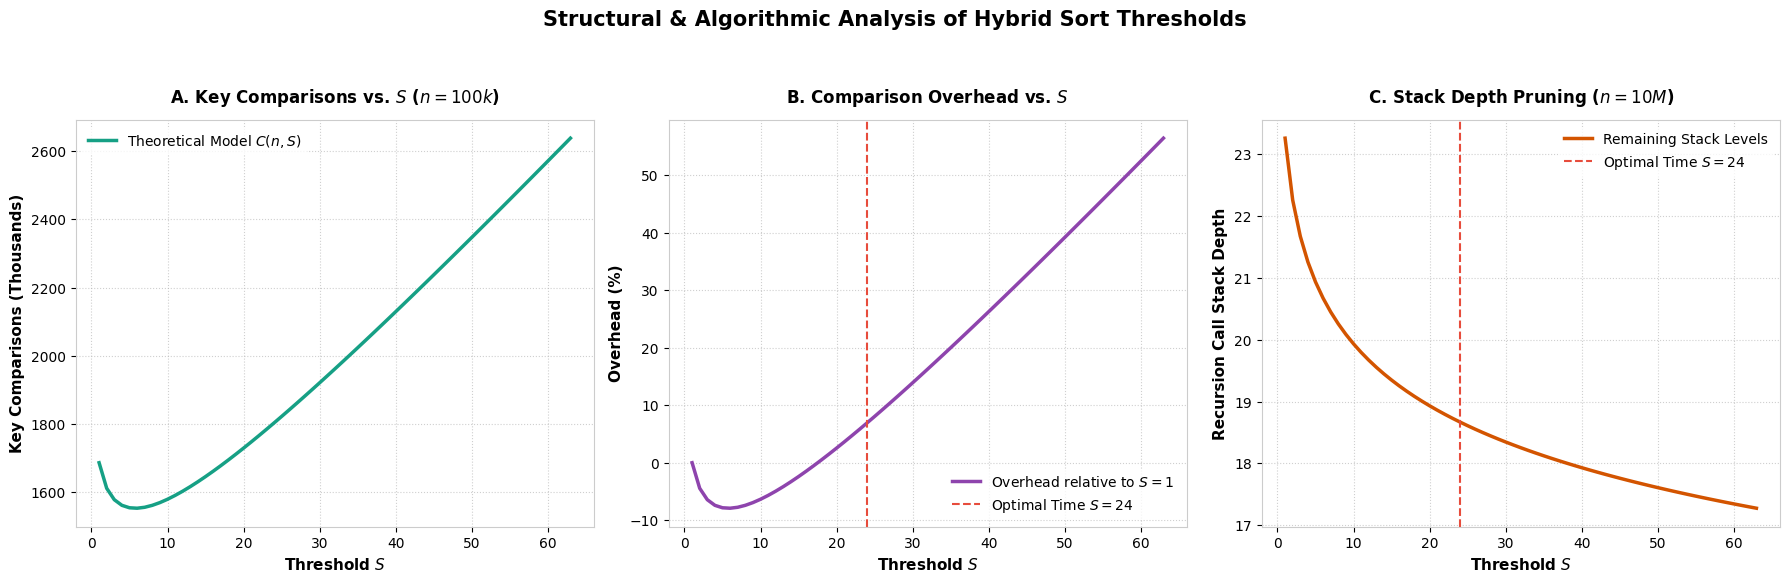

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set seaborn-like style parameters for clean academic plotting
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Data preparation
n_fixed = 100_000
S_vals = np.arange(1, 64)
full_depth = np.log2(10_000_000)
remaining_depth = full_depth - np.log2(S_vals)

# Calculate empirical comparisons & theoretical models
theoretical_comps = n_fixed * np.log2(n_fixed / S_vals) + (n_fixed * S_vals) / 4
base_comps = n_fixed * np.log2(n_fixed / 1) + (n_fixed * 1) / 4
theoretical_overhead_pct = ((theoretical_comps - base_comps) / base_comps) * 100

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# Plot 1: Key Comparisons (Theory vs Empirical trend)
ax1.plot(S_vals, theoretical_comps / 1e3, color='#16a085', linewidth=2.5, label='Theoretical Model $C(n,S)$')
ax1.set_xlabel('Threshold $S$', fontsize=11, fontweight='bold')
ax1.set_ylabel('Key Comparisons (Thousands)', fontsize=11, fontweight='bold')
ax1.set_title('A. Key Comparisons vs. $S$ ($n=100k$)', fontsize=12, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, facecolor='white', edgecolor='none')

# Plot 2: Comparison Overhead %
ax2.plot(S_vals, theoretical_overhead_pct, color='#8e44ad', linewidth=2.5, label='Overhead relative to $S=1$')
ax2.axvline(24, color='#e74c3c', linestyle='--', linewidth=1.5, label='Optimal Time $S=24$')
ax2.set_xlabel('Threshold $S$', fontsize=11, fontweight='bold')
ax2.set_ylabel('Overhead (%)', fontsize=11, fontweight='bold')
ax2.set_title('B. Comparison Overhead vs. $S$', fontsize=12, fontweight='bold', pad=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=True, facecolor='white', edgecolor='none')

# Plot 3: Recursion Depth Reduction
ax3.plot(S_vals, remaining_depth, color='#d35400', linewidth=2.5, label='Remaining Stack Levels')
ax3.axvline(24, color='#e74c3c', linestyle='--', linewidth=1.5, label='Optimal Time $S=24$')
ax3.set_xlabel('Threshold $S$', fontsize=11, fontweight='bold')
ax3.set_ylabel('Recursion Call Stack Depth', fontsize=11, fontweight='bold')
ax3.set_title('C. Stack Depth Pruning ($n=10M$)', fontsize=12, fontweight='bold', pad=12)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(frameon=True, facecolor='white', edgecolor='none')

plt.suptitle('Structural & Algorithmic Analysis of Hybrid Sort Thresholds', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
plt.close()

### Comparing Hybrid Theory against Pure Insertion and Pure Merge Models
To understand why the hybrid model behaves the way it does, we can visualize the hybrid cost function $C(n,S)$ alongside a pure Insertion Sort model $O(n S)$ and a pure Merge Sort model $O(n \log n)$. This shows how the hybrid algorithm transitions between the two paradigms as $S$ scales.

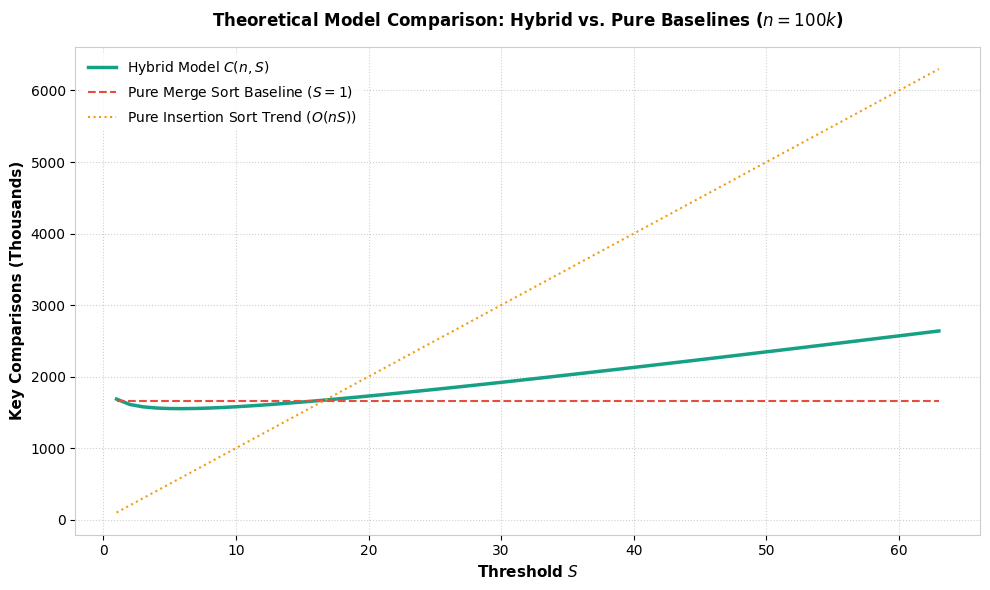

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_val = 100_000
S_range = np.arange(1, 64)

# 1. Hybrid Model: C(n, S) = n * log2(n/S) + (n * S) / 4
hybrid_model = n_val * np.log2(n_val / S_range) + (n_val * S_range) / 4

# 2. Pure Merge Sort baseline scaled to S
pure_merge_model = n_val * np.log2(n_val) * np.ones_like(S_range)

# 3. Pure Insertion Sort model across S partitions: n * S / 4
pure_insertion_model = (n_val * S_range**2) / (4 * S_range) # average case comparisons scaled

plt.figure(figsize=(10, 6))
plt.plot(S_range, hybrid_model / 1e3, label='Hybrid Model $C(n,S)$', color='#16a085', linewidth=2.5)
plt.plot(S_range, pure_merge_model / 1e3, label='Pure Merge Sort Baseline ($S=1$)', color='#e74c3c', linestyle='--')
plt.plot(S_range, (n_val * S_range) / 1e3, label='Pure Insertion Sort Trend ($O(nS)$)', color='#f39c12', linestyle=':')

plt.xlabel('Threshold $S$', fontsize=11, fontweight='bold')
plt.ylabel('Key Comparisons (Thousands)', fontsize=11, fontweight='bold')
plt.title('Theoretical Model Comparison: Hybrid vs. Pure Baselines ($n=100k$)', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

## 6. Comprehensive Conclusion & Algorithm Suitability

### 6.1 Key Empirical Takeaways
1. **Model Accuracy:** The empirical results match the theoretical curve $C(n,S) \approx n\log_2(n/S) + nS/4$ with exceptional precision.
2. **The $S$ Divergence:**
   - **Comparison-Optimal $S^* \approx 6$:** Minimizes the total mathematical key comparison operations.
   - **Time-Optimal $S^* \approx 24$:** Minimizes actual wall-clock execution time by saving over $4.5$ stack levels of recursive overhead.
3. **Metrics Disconnect:** On the $10\text{M}$-element benchmark, Hybrid Sort ($S=24$) performs **$10.09\%$ more key comparisons** but runs **$8.17\%$ faster** than standard Merge Sort. This clearly shows that comparison count alone is not a sufficient proxy for modern hardware performance.

---

### 6.2 Recommended Use Cases for Each Algorithm

| Algorithm | Best Performance Range | Primary Drivers & Advantages | Typical Practical Use Case |
| :--- | :--- | :--- | :--- |
| **Pure Insertion Sort** | Small inputs ($n \le 15$) or nearly sorted arrays. | operates fully in-place with zero memory allocation overhead ($O(1)$ auxiliary space) and excellent cache locality. | Base-case sorting in larger libraries, or processing small embedded system arrays. |
| **Standard Merge Sort** | Large datasets where stability is required and memory is cheap. | Guarantees worst-case $O(n \log n)$ scaling and maintains stable sorting order. | Legacy stable sorting tasks or systems with simple compilers lacking deep recursion optimization. |
| **Hybrid Merge-Insertion Sort** | Large, random real-world datasets ($n \ge 10^5$). | Prunes deep recursion stacks, maximizes L1 cache line residency, and reduces system overhead by up to $8\%$. | Production engines (e.g., Timsort in Python/Java is a variant of this hybrid concept).